# Tutorial 2: Defining Rotor Data (`module_rotor`)

This tutorial explains how to define rotor performance curves (e.g., Cp vs TSR and Ct vs TSR) using rotor data files. Follow the steps below to process rotor data.

1. **Import Required Modules**  
   Import the `RotorData` class from the `vital.module_rotor` module and other necessary libraries for data processing and visualization.

In [1]:
from vital.module_rotor import RotorData
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2. **Load Rotor Data**  
   Load rotor performance data from a text file. You can use either the Sitkana Rotor Data or Sandia Rotor Data.

In [2]:
# Sitkana Rotor Data
RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_2.txt"
rotor = RotorData(RotorPerformanceFile)

# Sandia Rotor Data (optional)
# RotorPerformanceFile = "../data/Sandia_rotor_data.txt"
# cpmin_filename = "../data/Cpmin_data.json"
# rotor = RotorData(RotorPerformanceFile, cpmin_filename)

3. **Access Optimal Cp and TSR Values**  
   Retrieve the optimal Cp (power coefficient) and TSR (tip-speed ratio) values.

In [3]:
print(f"Optimal Cp: {rotor.CpOpt}")
print(f"Optimal TSR: {rotor.TSROpt}")

Optimal Cp: 0.21189
Optimal TSR: 0.76477


4. **Interpolate Rotor Performance Values**  
   Interpolate Cp, Ct, and Cq values for a specific TSR.

In [4]:
tsr_value = 1.0
cp_value = rotor.get_cp(tsr_value)
ct_value = rotor.get_ct(tsr_value)
cq_value = rotor.get_cq(tsr_value)

print(f"Cp at TSR {tsr_value}: {cp_value}")
print(f"Ct at TSR {tsr_value}: {ct_value}")
print(f"Cq at TSR {tsr_value}: {cq_value}")

Cp at TSR 1.0: 0.198340234472437
Ct at TSR 1.0: 0.5494085931653778
Cq at TSR 1.0: 0.19953030669218183


5. **Find Maximum TSR**  
   Determine the maximum TSR where Cp or Ct becomes zero.

In [5]:
tsr_max = rotor.find_tsr_max()
print(f"Maximum TSR where Cp or Ct becomes zero: {tsr_max}")

Maximum TSR where Cp or Ct becomes zero: 1.5917844474474474


6. **Visualize Rotor Performance Curves**  
   Plot Cp, Ct, Cq, and Cpmin curves against TSR values to analyze rotor performance.

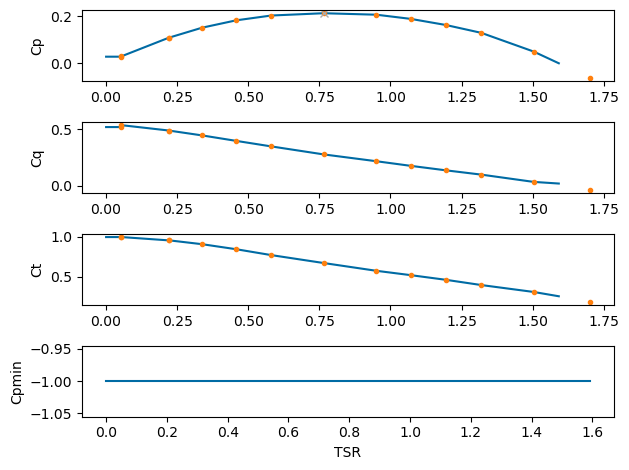

In [6]:
TSR_val = np.linspace(0.0, tsr_max, 100)
data = pd.read_csv(RotorPerformanceFile, delimiter='\t')

plt.figure(figsize=(6.4, 4.8))

# Plot Cp
plt.subplot(4, 1, 1)
plt.plot(TSR_val, rotor.get_cp(TSR_val))
plt.plot(data['TSR'], data['Cp'], '.')
plt.plot(rotor.TSROpt, rotor.CpOpt, 'x')
plt.ylabel('Cp')

# Plot Cq
plt.subplot(4, 1, 2)
plt.plot(TSR_val, rotor.get_cq(TSR_val))
plt.plot(data['TSR'], data['Cp'] / data['TSR'], '.')
plt.ylabel('Cq')

# Plot Ct
plt.subplot(4, 1, 3)
plt.plot(TSR_val, rotor.get_ct(TSR_val))
plt.plot(data['TSR'], data['Ct'], '.')
plt.ylabel('Ct')

# Plot Cpmin
plt.subplot(4, 1, 4)
plt.plot(TSR_val, rotor.get_cpmin(TSR_val))
plt.ylabel('Cpmin')

plt.xlabel('TSR')
plt.tight_layout()
plt.show()